In [1]:
import numpy as np
import matplotlib.pyplot as plt

# S_n implementation as mathematic formulas in 1.55

$$ S_n(t) = \sum_{p=0}^{n-1}d(t-2pT) $$

$ S_0(t) = 0 $ \
$ S_1(t) = d(t) $ \
$ S_2(t) = d(t) + d(t-2T) $

$S_n$ is a sum on $n$ elements where the first is 0 while the consecutive elements are a cumulative sum of distances between the mirrors in $2T$ time steps. We can say that this cumulative sum looks time backward.

In [29]:
def S_n_linear(n, d):
    """
    Rakhmanov Eq. 1.55

    d is a list of distances. It must be longer than n.
    """
    
    S_n = 0.
    for i in range(n):
        S_n += d[-i-1]

    return S_n

In [30]:
S_n_linear(0, 0.1)

0.0

In [ ]:
# Constants for tests
Z_start = 1.2  # Initial mirror position
Z = 2.3        # Final mirror position
N = 100

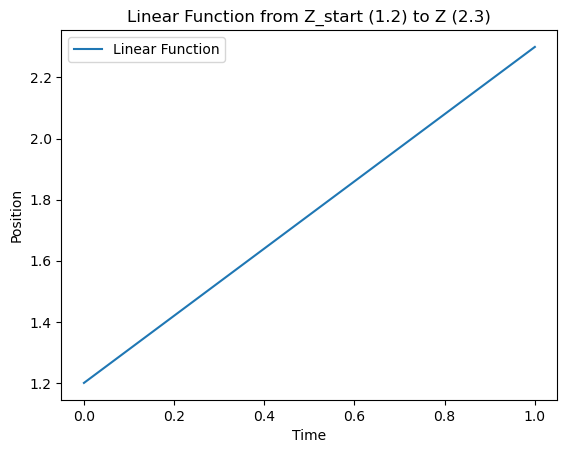

In [74]:
# Generate time values from 0 to 1
time = np.linspace(0, 1, N)

# Generate linear function values
linear_function = np.linspace(Z_start, Z, N)

# Plot the linear function
plt.plot(time, linear_function, label='Linear Function')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Linear Function from Z_start ({0}) to Z ({1})'.format(Z_start, Z))
plt.legend()
plt.show()

In [141]:
S_n_linear(2, linear_function)

4.588888888888889

In [89]:
def transform_distances(d_t):
    """
    Transform distances by applying an arbitrary function.
    This function is used to test the S_n_linear for function movement of the mirror.

    Rakhmanov Eq. 1.56
    """
    return d_t
    #return np.sin(2 * np.pi * d_t)

In [142]:
# Create a list of distances for S_n_linear

d_t = np.linspace(Z_start, Z, N)
d_t = transform_distances(d_t)

print("d_t[{}]:".format(len(d_t)))
print(d_t)

a = S_n_linear(100, d_t)
print(a)

d_t[100]:
[1.2        1.21111111 1.22222222 1.23333333 1.24444444 1.25555556
 1.26666667 1.27777778 1.28888889 1.3        1.31111111 1.32222222
 1.33333333 1.34444444 1.35555556 1.36666667 1.37777778 1.38888889
 1.4        1.41111111 1.42222222 1.43333333 1.44444444 1.45555556
 1.46666667 1.47777778 1.48888889 1.5        1.51111111 1.52222222
 1.53333333 1.54444444 1.55555556 1.56666667 1.57777778 1.58888889
 1.6        1.61111111 1.62222222 1.63333333 1.64444444 1.65555556
 1.66666667 1.67777778 1.68888889 1.7        1.71111111 1.72222222
 1.73333333 1.74444444 1.75555556 1.76666667 1.77777778 1.78888889
 1.8        1.81111111 1.82222222 1.83333333 1.84444444 1.85555556
 1.86666667 1.87777778 1.88888889 1.9        1.91111111 1.92222222
 1.93333333 1.94444444 1.95555556 1.96666667 1.97777778 1.98888889
 2.         2.01111111 2.02222222 2.03333333 2.04444444 2.05555556
 2.06666667 2.07777778 2.08888889 2.1        2.11111111 2.12222222
 2.13333333 2.14444444 2.15555556 2.16666667 2.17777

In [143]:
# Generate the list of integrated distances using S_n_linear function

Ze_acc_S_n = []
for i in range(N+1):
    Ze_acc_S_n.append(S_n_linear(i, d_t))

print("Ze_acc_S_n[{0}]:".format(len(Ze_acc_S_n)))
print(np.array(Ze_acc_S_n))

Ze_acc_S_n[101]:
[  0.           2.3          4.58888889   6.86666667   9.13333333
  11.38888889  13.63333333  15.86666667  18.08888889  20.3
  22.5         24.68888889  26.86666667  29.03333333  31.18888889
  33.33333333  35.46666667  37.58888889  39.7         41.8
  43.88888889  45.96666667  48.03333333  50.08888889  52.13333333
  54.16666667  56.18888889  58.2         60.2         62.18888889
  64.16666667  66.13333333  68.08888889  70.03333333  71.96666667
  73.88888889  75.8         77.7         79.58888889  81.46666667
  83.33333333  85.18888889  87.03333333  88.86666667  90.68888889
  92.5         94.3         96.08888889  97.86666667  99.63333333
 101.38888889 103.13333333 104.86666667 106.58888889 108.3
 110.         111.68888889 113.36666667 115.03333333 116.68888889
 118.33333333 119.96666667 121.58888889 123.2        124.8
 126.38888889 127.96666667 129.53333333 131.08888889 132.63333333
 134.16666667 135.68888889 137.2        138.7        140.18888889
 141.66666667 143.133

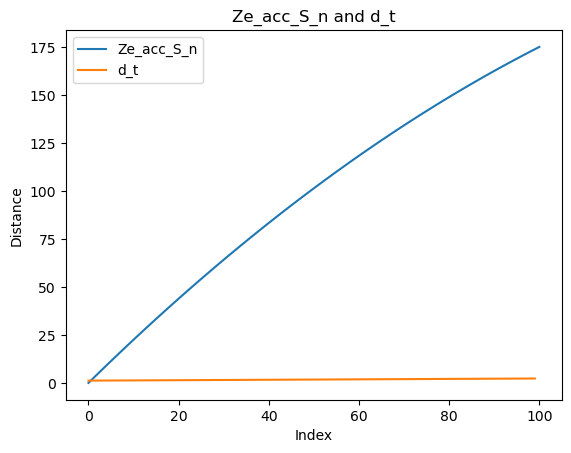

In [144]:
plt.plot(Ze_acc_S_n, label='Ze_acc_S_n')
plt.plot(d_t, label='d_t')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Ze_acc_S_n and d_t')
plt.legend()

# S_n implementation in oreonspy

In [145]:
# To use np.add.accumulate and make it produce the first element 0, Ze must have the first element 0.

Ze = np.zeros(N + 1)
Ze[1:] = np.linspace(Z_start, Z, N, endpoint=True)[::-1]  # endpoint=True is not consistent with the oreosnpy code
Ze[0] = 0.

Ze = transform_distances(Ze)

print("Ze[{0}]:".format(len(Ze)))
print(Ze)

Ze_acc_oreonspy = np.add.accumulate(Ze)

print("Ze_acc_oreonspy[{0}]:".format(len(Ze_acc_oreonspy)))
print(Ze_acc_oreonspy)

Ze[101]:
[0.         2.3        2.28888889 2.27777778 2.26666667 2.25555556
 2.24444444 2.23333333 2.22222222 2.21111111 2.2        2.18888889
 2.17777778 2.16666667 2.15555556 2.14444444 2.13333333 2.12222222
 2.11111111 2.1        2.08888889 2.07777778 2.06666667 2.05555556
 2.04444444 2.03333333 2.02222222 2.01111111 2.         1.98888889
 1.97777778 1.96666667 1.95555556 1.94444444 1.93333333 1.92222222
 1.91111111 1.9        1.88888889 1.87777778 1.86666667 1.85555556
 1.84444444 1.83333333 1.82222222 1.81111111 1.8        1.78888889
 1.77777778 1.76666667 1.75555556 1.74444444 1.73333333 1.72222222
 1.71111111 1.7        1.68888889 1.67777778 1.66666667 1.65555556
 1.64444444 1.63333333 1.62222222 1.61111111 1.6        1.58888889
 1.57777778 1.56666667 1.55555556 1.54444444 1.53333333 1.52222222
 1.51111111 1.5        1.48888889 1.47777778 1.46666667 1.45555556
 1.44444444 1.43333333 1.42222222 1.41111111 1.4        1.38888889
 1.37777778 1.36666667 1.35555556 1.34444444 1.333333

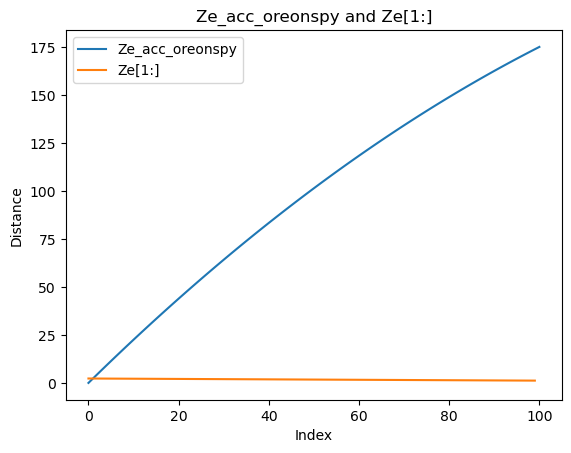

In [146]:
plt.plot(Ze_acc_oreonspy, label='Ze_acc_oreonspy')
plt.plot(Ze[1:], label='Ze[1:]')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Ze_acc_oreonspy and Ze[1:]')
plt.legend()

# Compare S_n_linear with oreonspy implementation

In [160]:
# Half-product: Distances (just for debug)
print("Ze[1:]-d_t[:] [{}]:".format(len(Ze)))
print(Ze[1:]-d_t[:])

Ze[1:]-d_t[:] [101]:
[ 1.1         1.07777778  1.05555556  1.03333333  1.01111111  0.98888889
  0.96666667  0.94444444  0.92222222  0.9         0.87777778  0.85555556
  0.83333333  0.81111111  0.78888889  0.76666667  0.74444444  0.72222222
  0.7         0.67777778  0.65555556  0.63333333  0.61111111  0.58888889
  0.56666667  0.54444444  0.52222222  0.5         0.47777778  0.45555556
  0.43333333  0.41111111  0.38888889  0.36666667  0.34444444  0.32222222
  0.3         0.27777778  0.25555556  0.23333333  0.21111111  0.18888889
  0.16666667  0.14444444  0.12222222  0.1         0.07777778  0.05555556
  0.03333333  0.01111111 -0.01111111 -0.03333333 -0.05555556 -0.07777778
 -0.1        -0.12222222 -0.14444444 -0.16666667 -0.18888889 -0.21111111
 -0.23333333 -0.25555556 -0.27777778 -0.3        -0.32222222 -0.34444444
 -0.36666667 -0.38888889 -0.41111111 -0.43333333 -0.45555556 -0.47777778
 -0.5        -0.52222222 -0.54444444 -0.56666667 -0.58888889 -0.61111111
 -0.63333333 -0.65555556 -0.67

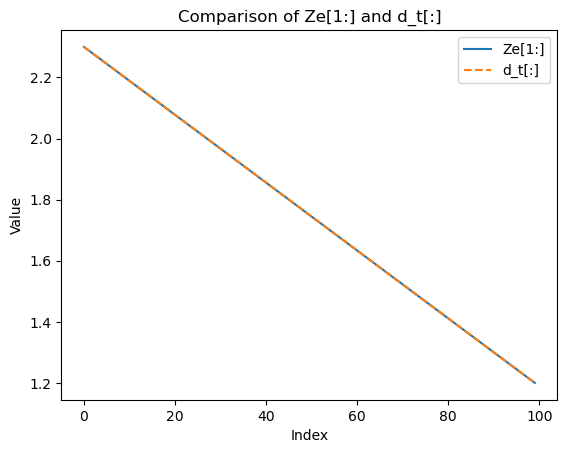

In [149]:
plt.plot(Ze[1:], label='Ze[1:]')
plt.plot(d_t[::-1], label='d_t[:]', ls='--')

plt.legend()
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of Ze[1:] and d_t[:]')
plt.show()

In [159]:
# Final product: Accumulated distances (relevant for calculation)
print("Ze_acc_oreonspy-Ze_acc_S_n [{}]:".format(len(Ze_acc_oreonspy)))
print(Ze_acc_oreonspy-Ze_acc_S_n)

Ze_acc_oreonspy-Ze_acc_S_n [101]:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


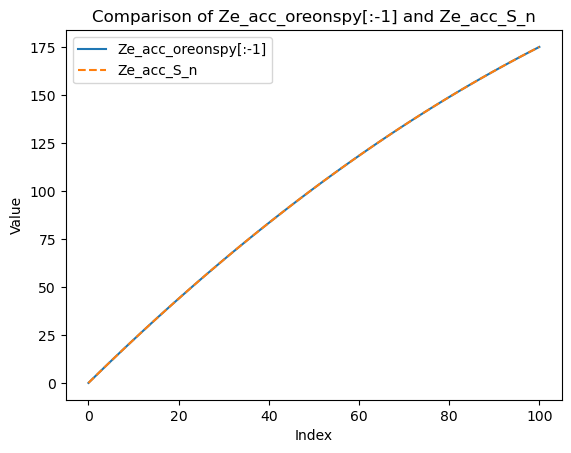

In [155]:
plt.plot(Ze_acc_oreonspy, label='Ze_acc_oreonspy[:-1]')
plt.plot(Ze_acc_S_n, label='Ze_acc_S_n', ls='--')

plt.legend()
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of Ze_acc_oreonspy[:-1] and Ze_acc_S_n')
plt.show()

# Conclusion

* To produce correctly ```Ze_acc_oreonspy``` by means of the ```np.add.accumulate()``` distances vector, ```Ze``` must contatin a zero at the first position;
* For the correct solution, the vector ```Ze``` must be produced from ```Z``` to ```Z_start``` with ```N``` steps;
* The above points result in ```Ze_acc_oreonspy``` being longer than ```Ze_acc_S_n``` produced in ```range(N)```;
* After shortening the ```Ze_acc_oreonspy```, the results of both methord are equal.

## Outcome for the simulator

* ```Ze``` must be produced corectly for the ```np.add.accumulate()```;
* The last element of the ```Ze_acc_oreonspy``` must be discarded.

# Attempt to generate ```Ze_acc_oreonspy``` faster

Idea:
- without inverting the matrix

In [135]:
# Reference array
print(Ze)

[0.         2.3        2.28888889 2.27777778 2.26666667 2.25555556
 2.24444444 2.23333333 2.22222222 2.21111111 2.2        2.18888889
 2.17777778 2.16666667 2.15555556 2.14444444 2.13333333 2.12222222
 2.11111111 2.1        2.08888889 2.07777778 2.06666667 2.05555556
 2.04444444 2.03333333 2.02222222 2.01111111 2.         1.98888889
 1.97777778 1.96666667 1.95555556 1.94444444 1.93333333 1.92222222
 1.91111111 1.9        1.88888889 1.87777778 1.86666667 1.85555556
 1.84444444 1.83333333 1.82222222 1.81111111 1.8        1.78888889
 1.77777778 1.76666667 1.75555556 1.74444444 1.73333333 1.72222222
 1.71111111 1.7        1.68888889 1.67777778 1.66666667 1.65555556
 1.64444444 1.63333333 1.62222222 1.61111111 1.6        1.58888889
 1.57777778 1.56666667 1.55555556 1.54444444 1.53333333 1.52222222
 1.51111111 1.5        1.48888889 1.47777778 1.46666667 1.45555556
 1.44444444 1.43333333 1.42222222 1.41111111 1.4        1.38888889
 1.37777778 1.36666667 1.35555556 1.34444444 1.33333333 1.3222

In [136]:
# Alternative way to generate the list of integrated distances using np.linspace
Ze_alternative = np.insert(np.linspace(Z, Z_start, N, endpoint=True), 0, 0., axis=0)

In [137]:
Ze_alternative

array([0.        , 2.3       , 2.28888889, 2.27777778, 2.26666667,
       2.25555556, 2.24444444, 2.23333333, 2.22222222, 2.21111111,
       2.2       , 2.18888889, 2.17777778, 2.16666667, 2.15555556,
       2.14444444, 2.13333333, 2.12222222, 2.11111111, 2.1       ,
       2.08888889, 2.07777778, 2.06666667, 2.05555556, 2.04444444,
       2.03333333, 2.02222222, 2.01111111, 2.        , 1.98888889,
       1.97777778, 1.96666667, 1.95555556, 1.94444444, 1.93333333,
       1.92222222, 1.91111111, 1.9       , 1.88888889, 1.87777778,
       1.86666667, 1.85555556, 1.84444444, 1.83333333, 1.82222222,
       1.81111111, 1.8       , 1.78888889, 1.77777778, 1.76666667,
       1.75555556, 1.74444444, 1.73333333, 1.72222222, 1.71111111,
       1.7       , 1.68888889, 1.67777778, 1.66666667, 1.65555556,
       1.64444444, 1.63333333, 1.62222222, 1.61111111, 1.6       ,
       1.58888889, 1.57777778, 1.56666667, 1.55555556, 1.54444444,
       1.53333333, 1.52222222, 1.51111111, 1.5       , 1.48888

# Verification

In [156]:
# Reference sum
print(Ze_acc_S_n[-1])

174.99999999999997


In [157]:
print(np.add.accumulate(Ze_alternative)[-1])

174.99999999999997


In [158]:
len(Ze_acc_S_n)

101